**Python DA Assignment 2 - Data Visualization**

1) Loading the Taxis Dataset
import seaborn as sns


In [1]:
import seaborn as sns

# Load the taxis dataset
df = sns.load_dataset("taxis")

# Display first 5 rows
df.head()

# Check dataset information
df.info()

# Check rows and columns
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

(6433, 14)

2) Handling Missing Values

➢ Check for missing values in the dataset and identify columns with missing data.

➢ Impute missing values using appropriate strategies based on the column type (e.g.,
using mean, median, or mode for numerical columns, and mode for categorical
columns).

➢ For columns that are critical and cannot be reasonably imputed, remove rows with
missing values to maintain data integrity.

In [2]:
# Check for missing values
print("Missing values before handling:")
print(df.isnull().sum())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include='number').columns
categorical_cols = df.select_dtypes(include='object').columns

# Fill missing numerical values with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Remove rows with missing values in critical columns
# Example:
# df = df.dropna(subset=['pickup'])

# Check missing values after handling
print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before handling:
pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

Missing values after handling:
pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


**3) Visualizations using Matplotlib/Pandas Plot:**

★ Line Chart  
Plot a line chart to visualize the fare over time, using the pickup timestamp as the
x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime
format before plotting.

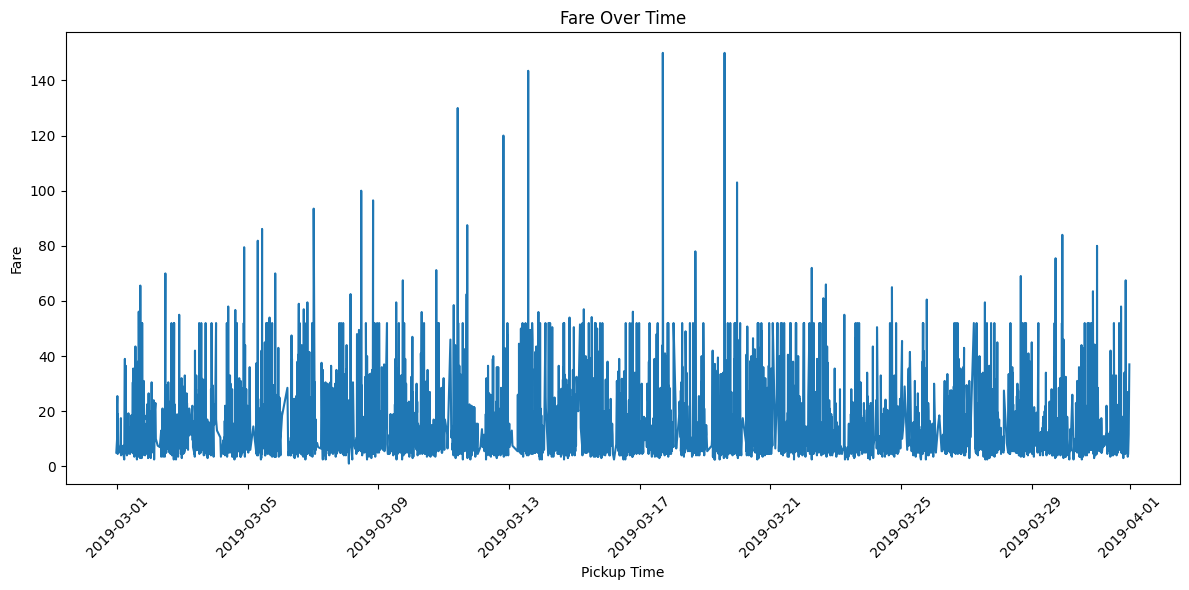

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert pickup column to datetime
df['pickup'] = pd.to_datetime(df['pickup'])

# Sort data by pickup time
df = df.sort_values('pickup')

# Plot line chart
plt.figure(figsize=(12, 6))
plt.plot(df['pickup'], df['fare'])

plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Fare Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

★ Bar Chart  
Create a bar chart to show the total fare for each pickup_borough. Group the data
by pickup_borough and sum the fare for each group.

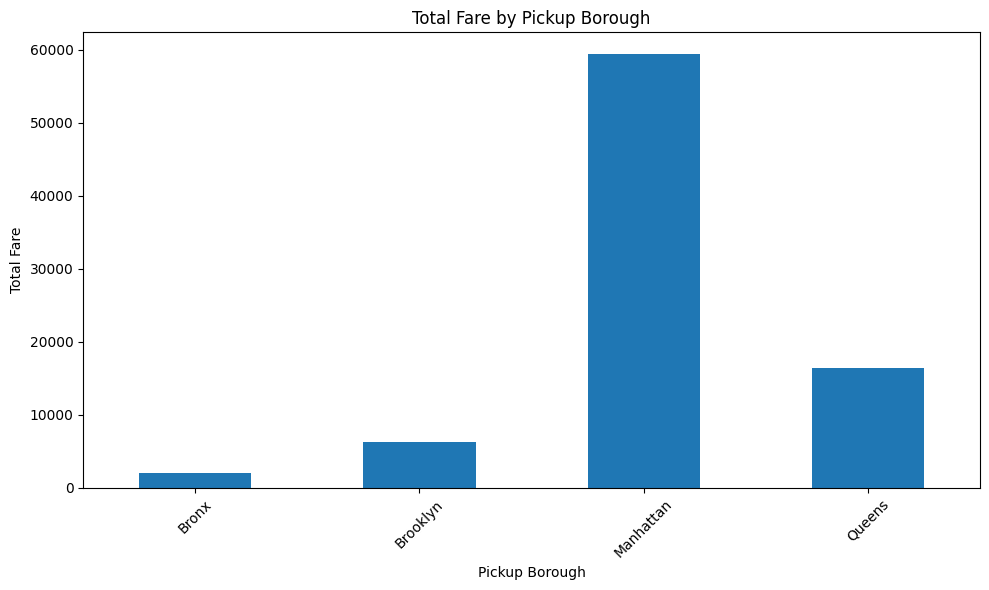

In [5]:
# Group by pickup_borough and calculate total fare
borough_fare = df.groupby('pickup_borough')['fare'].sum()

# Create bar chart
borough_fare.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Pickup Borough')
plt.ylabel('Total Fare')
plt.title('Total Fare by Pickup Borough')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

★ Pie Chart  
Plot a pie chart showing the distribution of trips based on the payment method (credit
card, cash, etc.). Each slice should represent the count of trips for a specific payment
method.

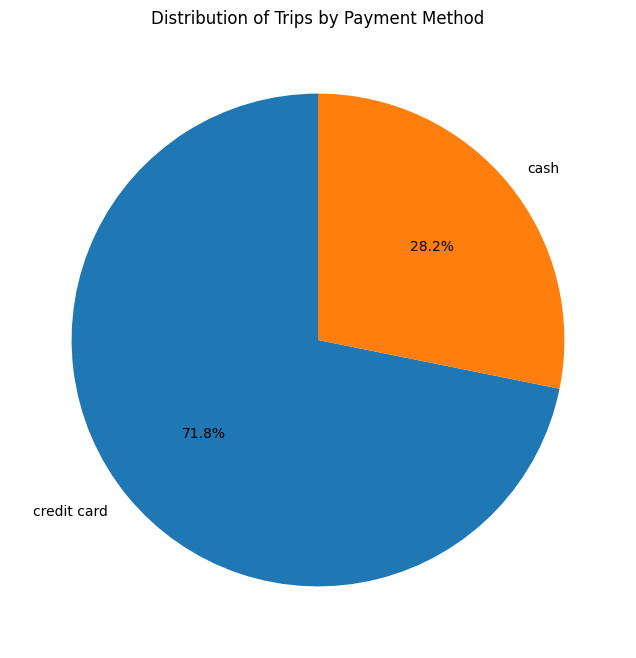

In [6]:
import matplotlib.pyplot as plt

# Count trips for each payment method
payment_counts = df['payment'].value_counts()

# Create pie chart
plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Trips by Payment Method')
plt.show()

★ Histogram  
Create a histogram to visualize the distribution of distance. Customize the number of
bins for better granularity and ensure the plot is easy to interpret

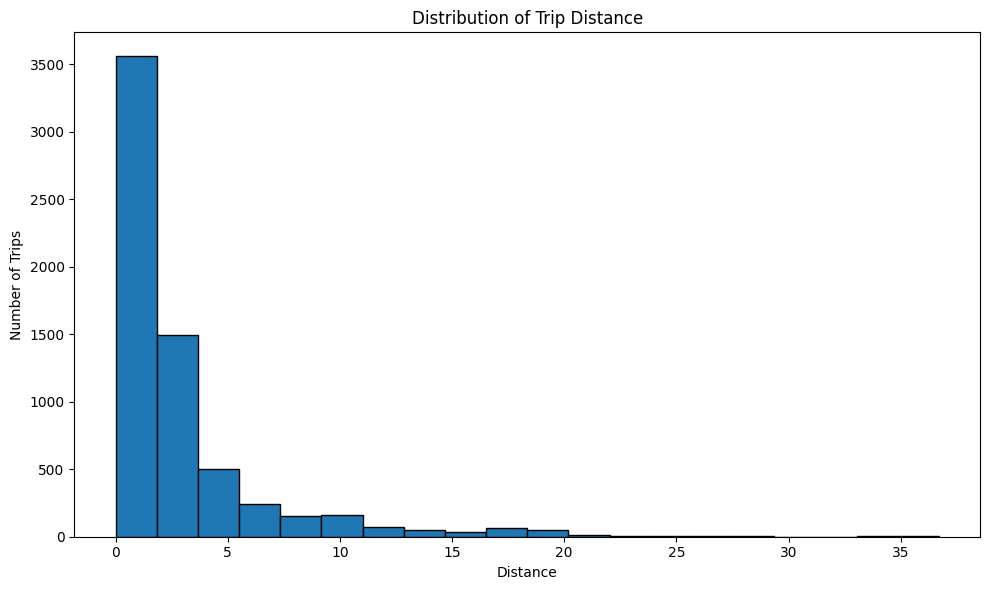

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(df['distance'], bins=20, edgecolor='black')

plt.xlabel('Distance')
plt.ylabel('Number of Trips')
plt.title('Distribution of Trip Distance')

plt.tight_layout()
plt.show()

★ Box Plot  
Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.
Use pickup_borough as the categorical axis and tip as the numeric axis.

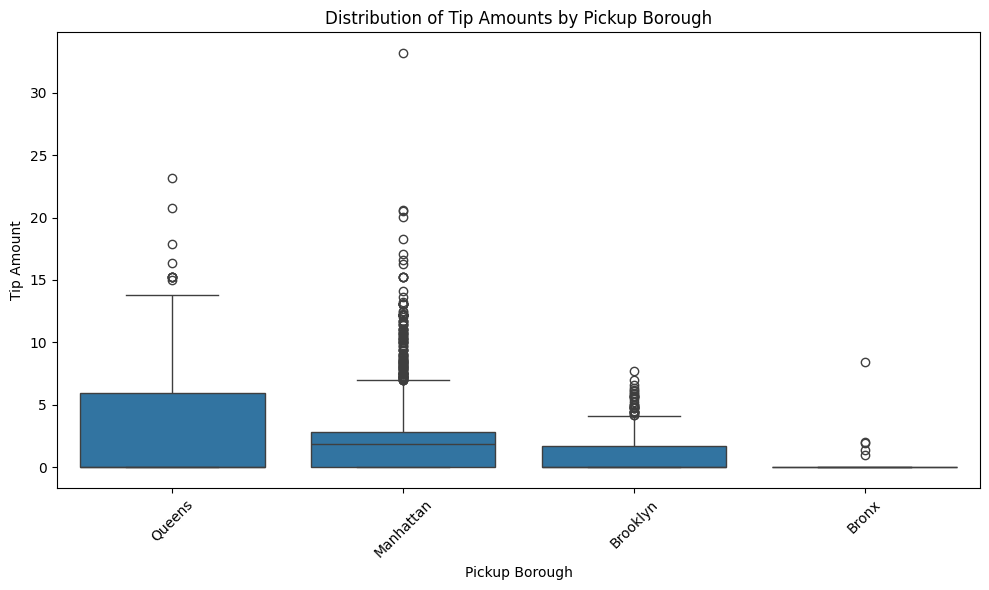

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='pickup_borough', y='tip')

plt.xlabel('Pickup Borough')
plt.ylabel('Tip Amount')
plt.title('Distribution of Tip Amounts by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Visualizations using Seaborn:**

★ Count Plot  
Create a count plot to visualize the number of trips in each pickup_borough. The
x-axis should represent the boroughs, and the y-axis should show the count of trips.

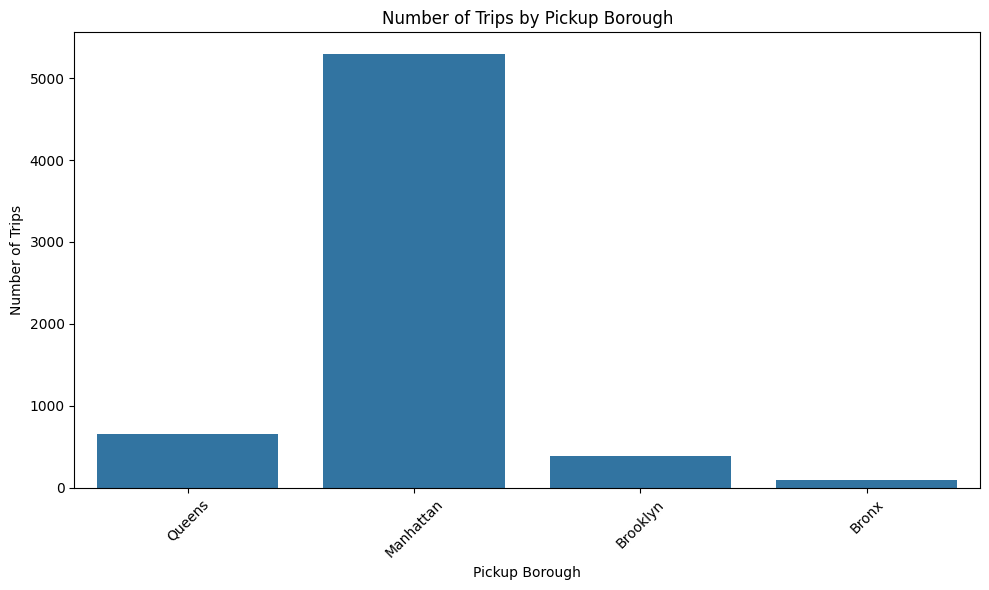

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(data=df, x='pickup_borough')

plt.xlabel('Pickup Borough')
plt.ylabel('Number of Trips')
plt.title('Number of Trips by Pickup Borough')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

★ Scatter Plot  
Plot a scatter plot to show the relationship between distance and fare. Use
distance on the x-axis and fare on the y-axis to visualize any correlation. Color the
points based on the pickup_borough to differentiate the trips by their respective
boroughs.

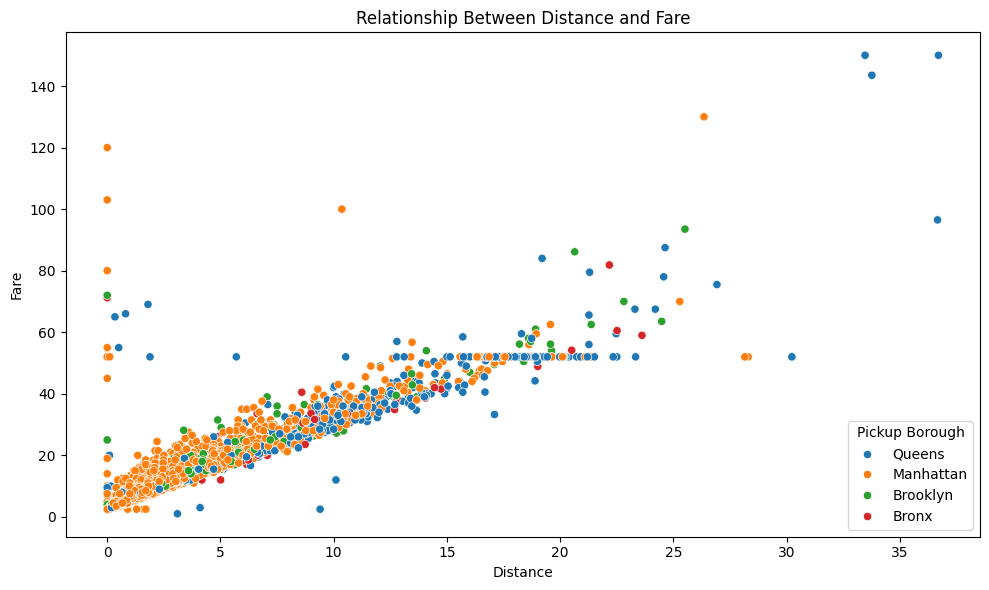

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='distance',
    y='fare',
    hue='pickup_borough')

plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship Between Distance and Fare')
plt.legend(title='Pickup Borough')
plt.tight_layout()
plt.show()

★ Heatmap  
Plot a heatmap to visualize the correlation between numerical variables such as
distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the
relationships

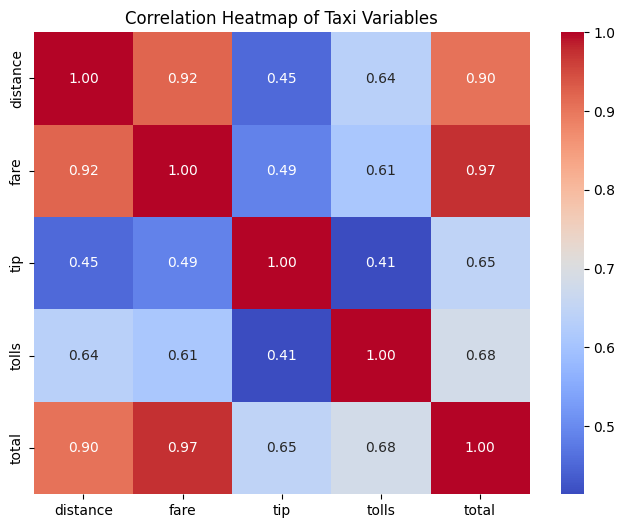

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns
numerical_cols = ['distance', 'fare', 'tip', 'tolls', 'total']

# Create correlation matrix
corr_matrix = df[numerical_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap of Taxi Variables')
plt.show()

★ Pair Plot  
Create a pair plot to visualize the pairwise relationships between distance, fare, tip,
and total. Color the data points according to the pickup_zone method to compare
how different zones affect these variables.

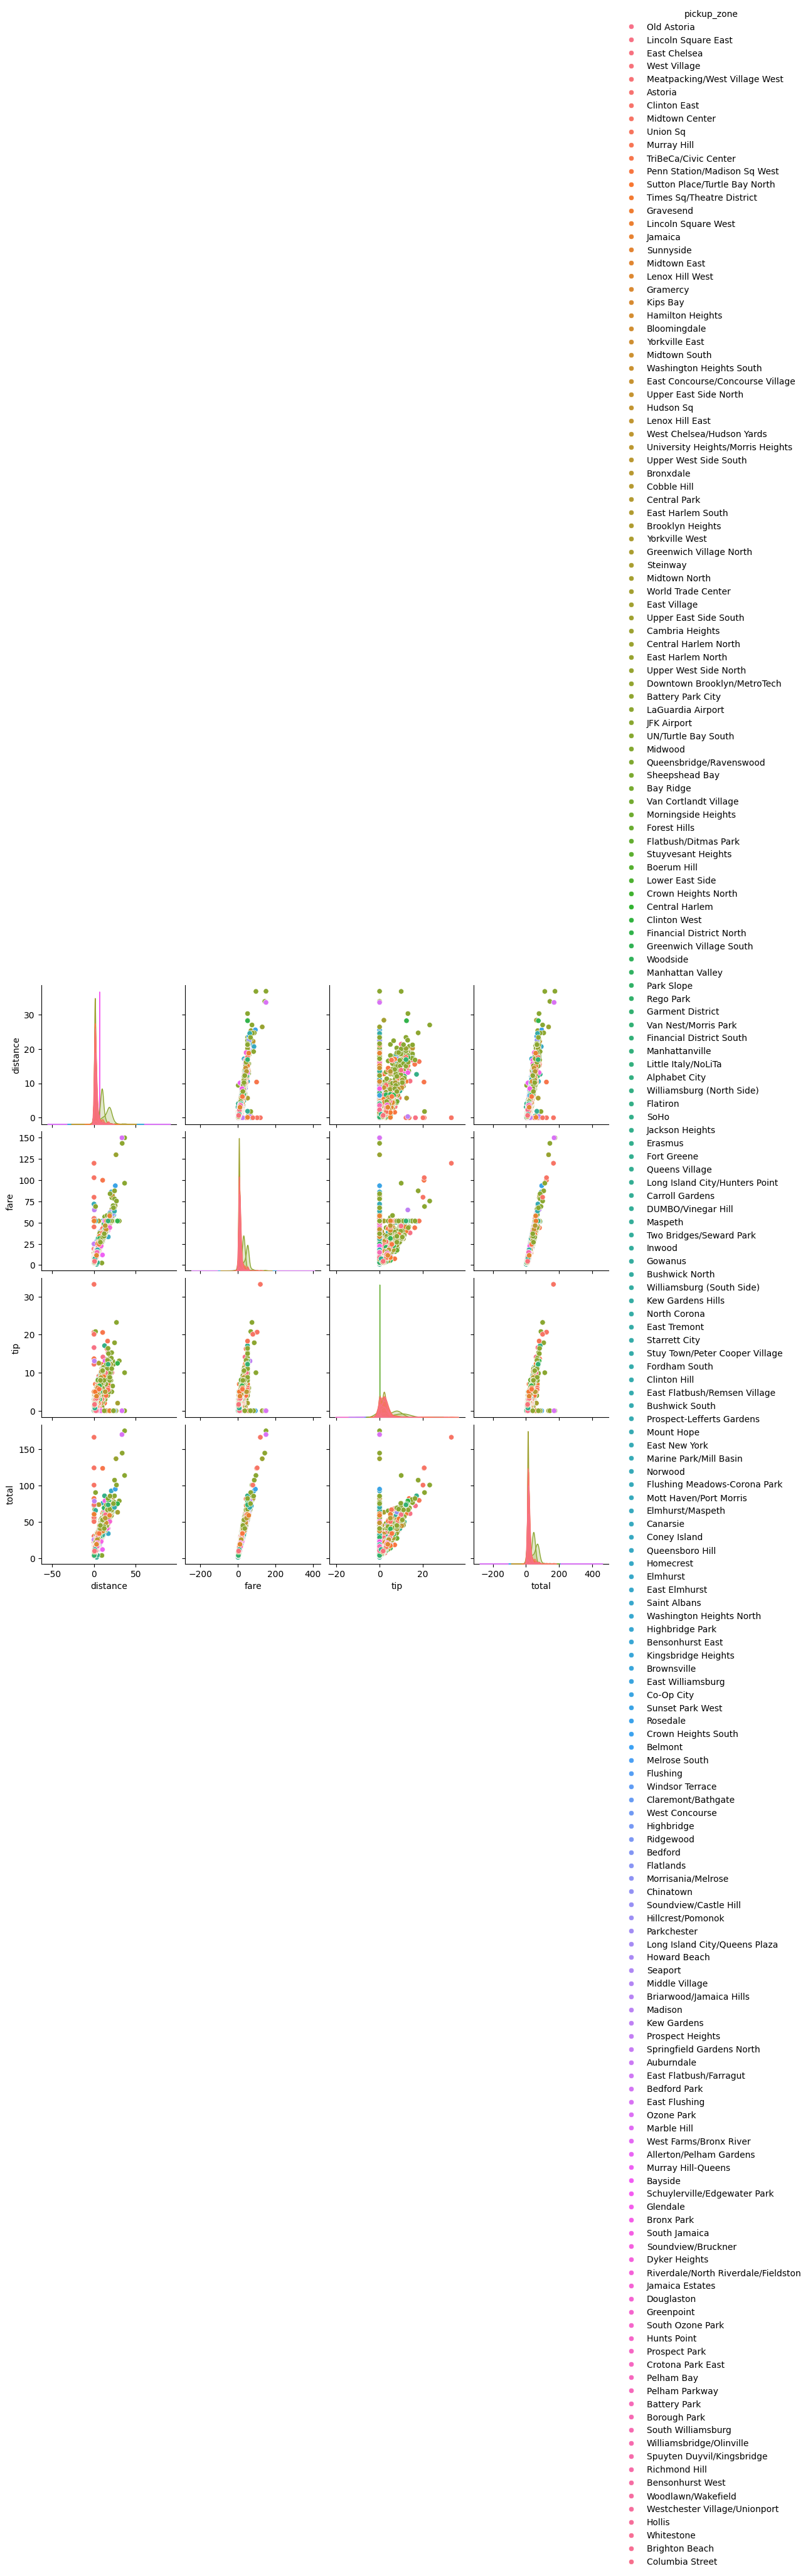

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the required columns
pairplot_data = df[['distance', 'fare', 'tip', 'total', 'pickup_zone']]

# Create pair plot
sns.pairplot(
    pairplot_data,
    vars=['distance', 'fare', 'tip', 'total'],
    hue='pickup_zone'
)

plt.show()

★ Violin Plot  
Plot a violin plot to show the distribution of fare for each payment method. Use the
payment method as the categorical axis and fare as the numeric axis to visualize its
distribution.

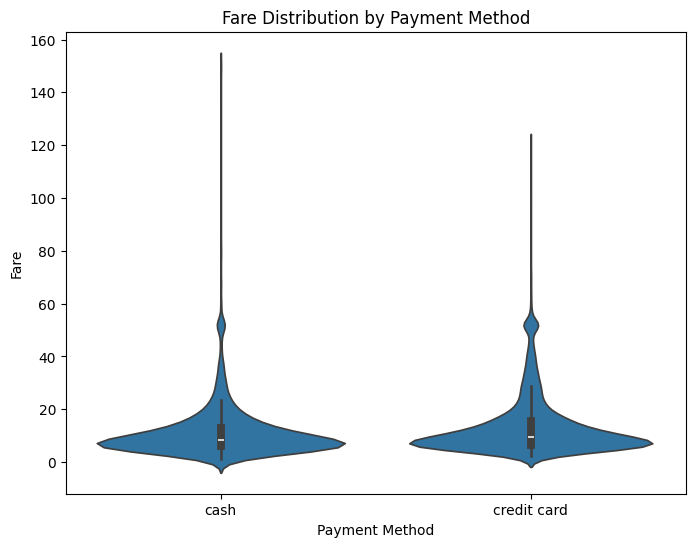

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create violin plot
plt.figure(figsize=(8, 6))

sns.violinplot(
    data=df,
    x='payment',
    y='fare'
)

plt.title('Fare Distribution by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Fare')

plt.show()